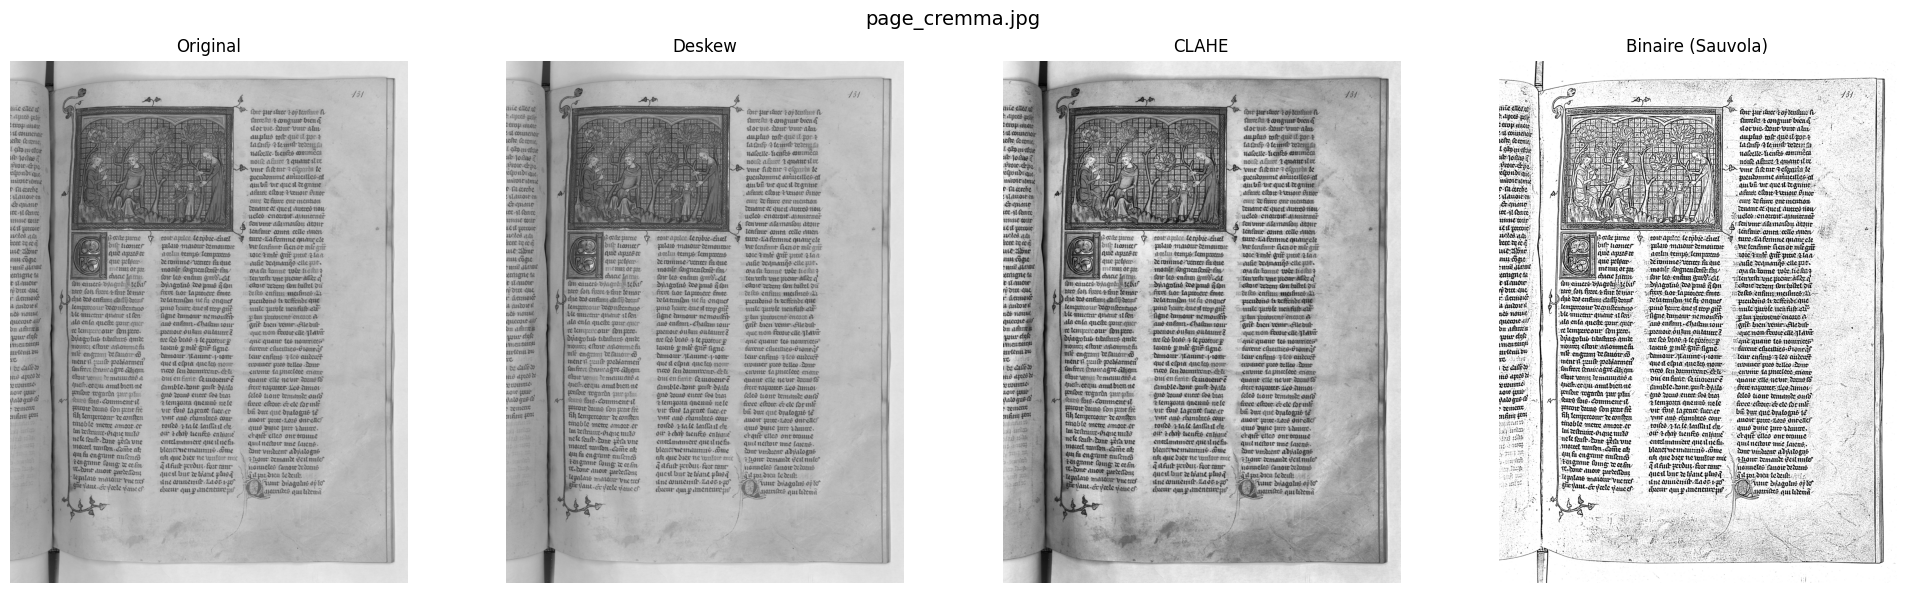

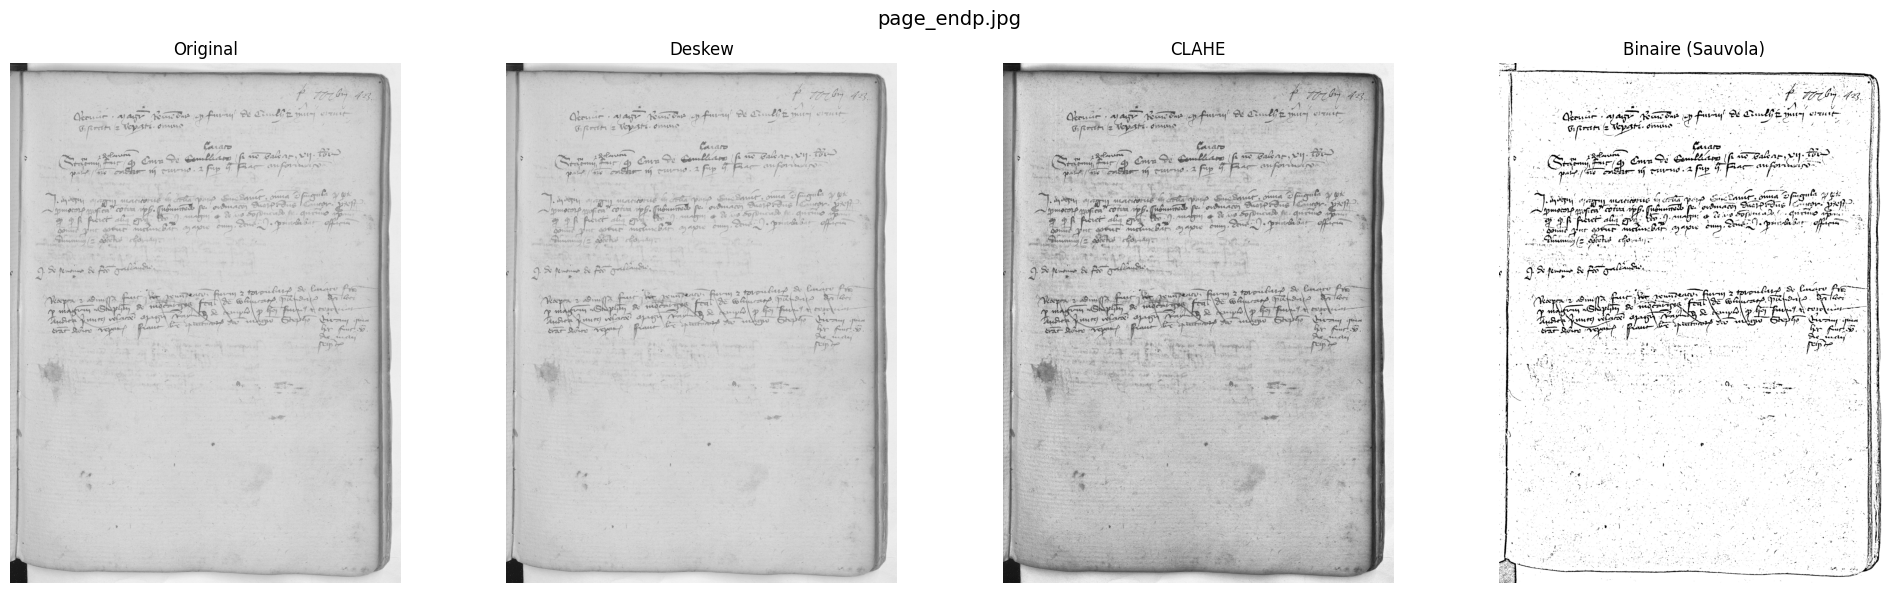

In [1]:
import sys
sys.path.append("..")

import cv2
import matplotlib.pyplot as plt
from src.preprocessing import preprocess_page

pages = [
    ("../dataset_nlp/raw_pages/page_cremma.jpg", 0.1),  # k=0.1 : encres pâles (CREMMA)
    ("../dataset_nlp/raw_pages/page_endp.jpg", 0.2),    # k=0.2 : registre tabulaire (e-NDP)
]

for img_path, k in pages:
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    result = preprocess_page(image, sauvola_k=k)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    titles = ["Original", "Deskew", "CLAHE", "Binaire (Sauvola)"]
    for ax, key, title in zip(axes, ["original", "deskewed", "clahe", "binary"], titles):
        ax.imshow(result[key], cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle(img_path.split('/')[-1], fontsize=14)
    plt.tight_layout()
    plt.show()

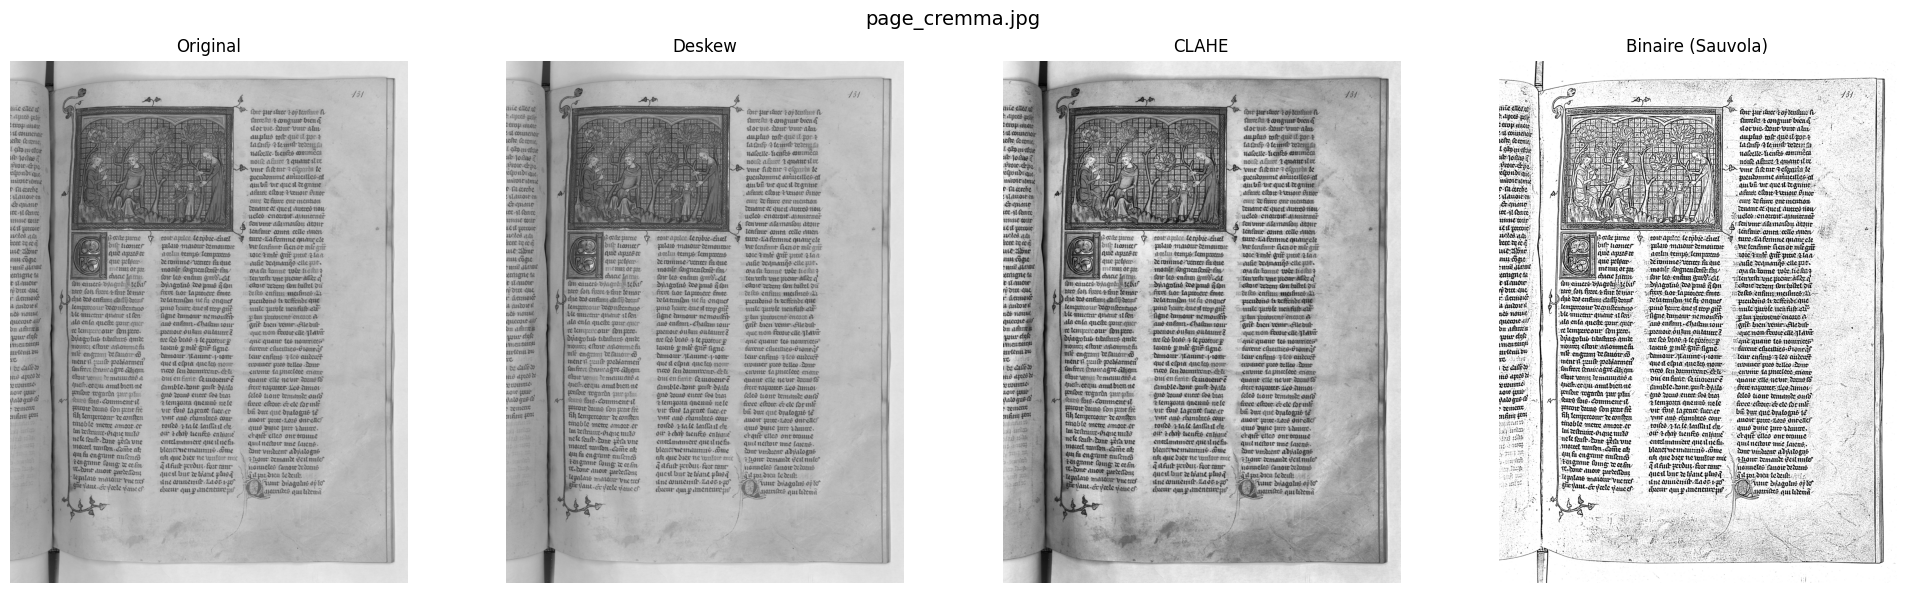

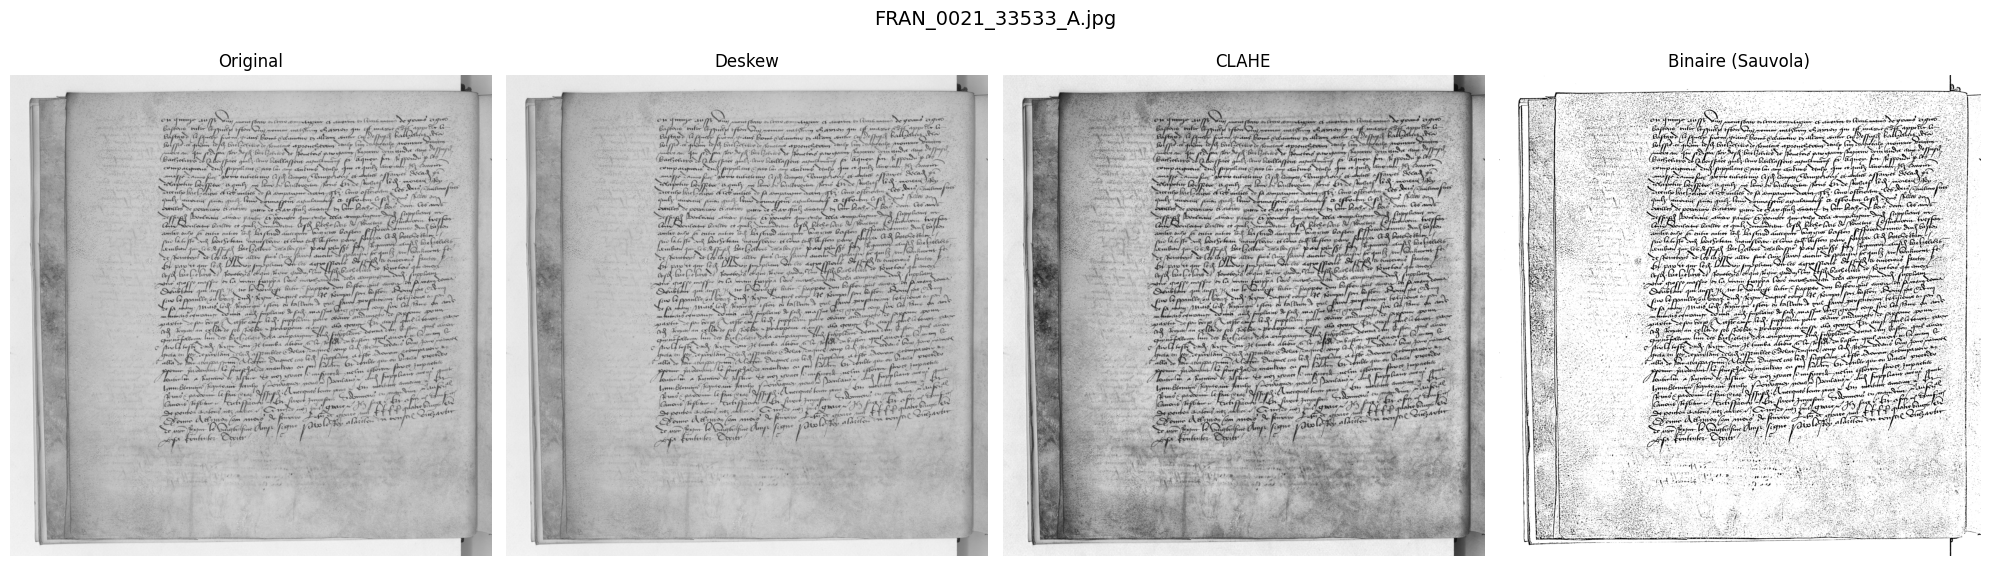

In [2]:
pages = [
    ("../dataset_nlp/raw_pages/page_cremma.jpg", 0.1),
    ("../dataset_nlp/raw_himanis/guerin2/Guerin(2)/FRAN_0021_33533_A.jpg", 0.2),
]

for img_path, k in pages:
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    result = preprocess_page(image, sauvola_k=k)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    titles = ["Original", "Deskew", "CLAHE", "Binaire (Sauvola)"]
    for ax, key, title in zip(axes, ["original", "deskewed", "clahe", "binary"], titles):
        ax.imshow(result[key], cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle(img_path.split('/')[-1], fontsize=14)
    plt.tight_layout()
    plt.show()

In [3]:
image_entree = "../dataset_nlp/raw_himanis/guerin2/Guerin(2)/FRAN_0021_33533_A.jpg"
json_sortie = "../dataset_nlp/processed_pages/segmentation_himanis.json"

!kraken -i "{image_entree}" {json_sortie} segment -bl

Segmenting ../dataset_nlp/raw_himanis/guerin2/Guerin(2)/FRAN_0021_33533_A.jpg	You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
✓


Kraken BLLA    : 47 lignes predites
Verite-terrain : 40 lignes annotees (Transkribus)

IoU moyen         : 0.604
IoU median        : 0.614
Lignes IoU > 0.85 : 0/40
Lignes IoU > 0.75 : 0/40
Lignes IoU = 0    : 0


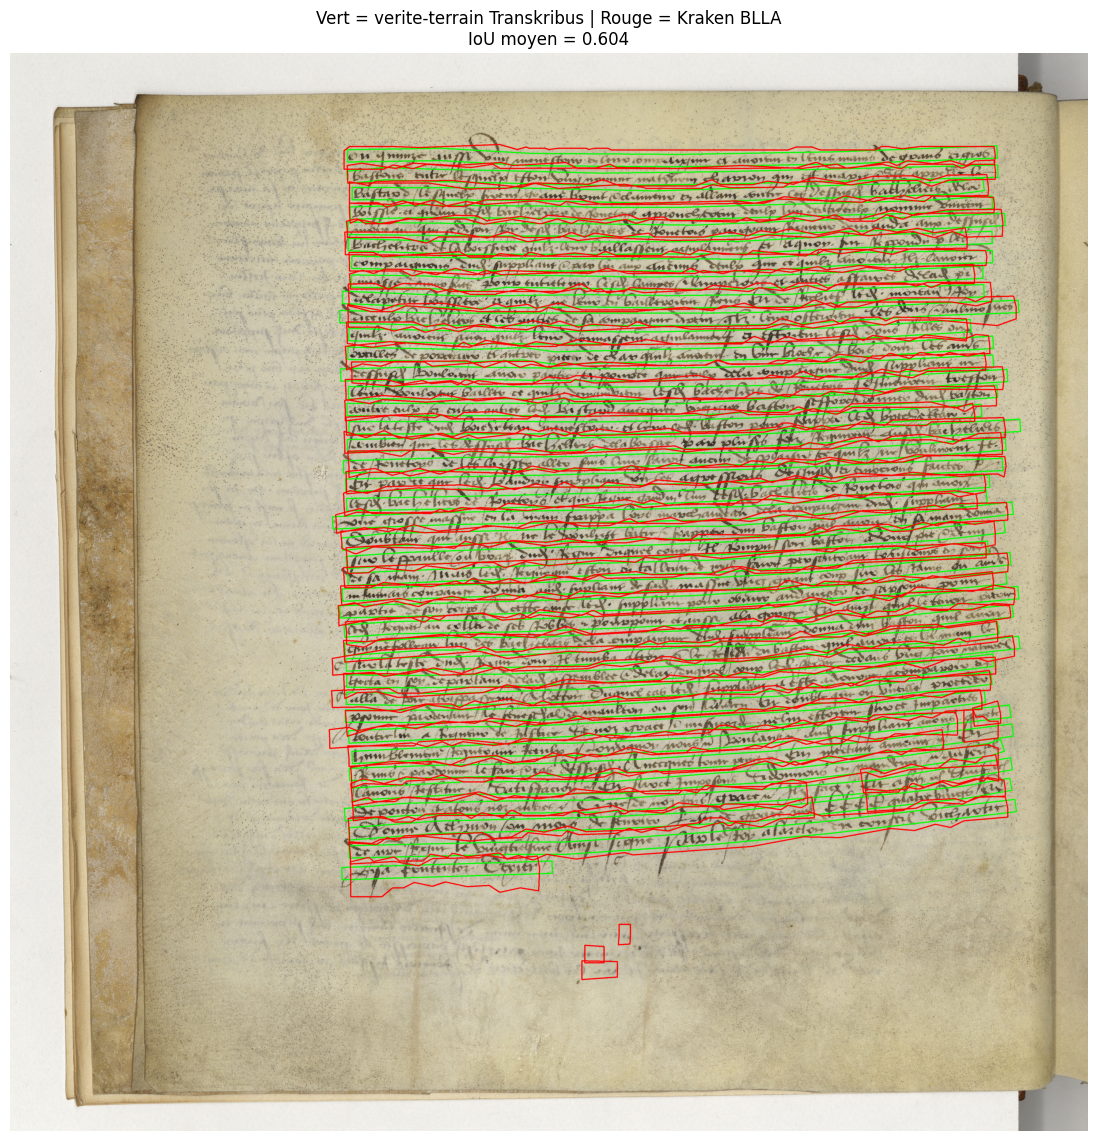

In [4]:
import json
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Polygones predits par Kraken BLLA
with open("../dataset_nlp/processed_pages/segmentation_himanis.json") as f:
    kraken_data = json.load(f)
pred_polygons = [line['boundary'] for line in kraken_data['lines']]

# 2. Polygones de verite-terrain (PAGE-XML Transkribus)
ns = {"pc": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}
root = ET.parse("../dataset_nlp/raw_himanis/guerin2/Guerin(2)/page/FRAN_0021_33533_A.xml").getroot()
gt_polygons = []
for tl in root.findall(".//pc:TextLine", ns):
    coords = tl.find("pc:Coords", ns)
    pts = [tuple(map(int, p.split(','))) for p in coords.get("points").split()]
    gt_polygons.append(pts)

print(f"Kraken BLLA    : {len(pred_polygons)} lignes predites")
print(f"Verite-terrain : {len(gt_polygons)} lignes annotees (Transkribus)")

# 3. IoU par rasterisation locale (pas de dependance externe type shapely)
def polygon_iou(poly1, poly2):
    poly1 = np.array(poly1, dtype=np.int32)
    poly2 = np.array(poly2, dtype=np.int32)
    all_pts = np.vstack([poly1, poly2])
    x_min, y_min = all_pts.min(axis=0)
    x_max, y_max = all_pts.max(axis=0)
    w, h = int(x_max - x_min + 1), int(y_max - y_min + 1)
    m1 = np.zeros((h, w), dtype=np.uint8)
    m2 = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(m1, [poly1 - [x_min, y_min]], 1)
    cv2.fillPoly(m2, [poly2 - [x_min, y_min]], 1)
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0.0

# 4. Appariement glouton : chaque ligne GT -> meilleure prediction disponible
used = set()
ious = []
for gt_poly in gt_polygons:
    best_iou, best_idx = 0.0, -1
    for i, pred_poly in enumerate(pred_polygons):
        if i in used:
            continue
        iou = polygon_iou(gt_poly, pred_poly)
        if iou > best_iou:
            best_iou, best_idx = iou, i
    if best_idx >= 0:
        used.add(best_idx)
    ious.append(best_iou)

ious = np.array(ious)
print(f"\nIoU moyen         : {ious.mean():.3f}")
print(f"IoU median        : {np.median(ious):.3f}")
print(f"Lignes IoU > 0.85 : {(ious > 0.85).sum()}/{len(ious)}")
print(f"Lignes IoU > 0.75 : {(ious > 0.75).sum()}/{len(ious)}")
print(f"Lignes IoU = 0    : {(ious == 0).sum()}")

# 5. Visualisation : vert = verite-terrain, rouge = Kraken BLLA
image = cv2.cvtColor(cv2.imread(image_entree), cv2.COLOR_BGR2RGB)
for pts in gt_polygons:
    cv2.polylines(image, [np.array(pts, dtype=np.int32)], True, (0, 255, 0), 4)
for pts in pred_polygons:
    cv2.polylines(image, [np.array(pts, dtype=np.int32)], True, (255, 0, 0), 4)

plt.figure(figsize=(14, 14))
plt.imshow(image)
plt.title(f"Vert = verite-terrain Transkribus | Rouge = Kraken BLLA\nIoU moyen = {ious.mean():.3f}")
plt.axis('off')
plt.show()

IoU de cette ligne          : 0.657
Hauteur GT (Transkribus)    : 85 px
Hauteur Kraken (predite)    : 100 px
Ratio Kraken/GT             : 1.18x


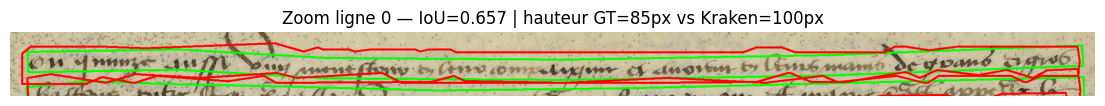

In [5]:
# Zoom diagnostic sur la ligne GT n°0 et son meilleur match Kraken
gt_poly = np.array(gt_polygons[0], dtype=np.int32)
best_iou, best_pred = 0, None
for pred_poly in pred_polygons:
    iou = polygon_iou(gt_polygons[0], pred_poly)
    if iou > best_iou:
        best_iou, best_pred = iou, np.array(pred_poly, dtype=np.int32)

gt_height = gt_poly[:, 1].max() - gt_poly[:, 1].min()
pred_height = best_pred[:, 1].max() - best_pred[:, 1].min()
print(f"IoU de cette ligne          : {best_iou:.3f}")
print(f"Hauteur GT (Transkribus)    : {gt_height} px")
print(f"Hauteur Kraken (predite)    : {pred_height} px")
print(f"Ratio Kraken/GT             : {pred_height / gt_height:.2f}x")

x_min = min(gt_poly[:,0].min(), best_pred[:,0].min()) - 30
x_max = max(gt_poly[:,0].max(), best_pred[:,0].max()) + 30
y_min = max(0, min(gt_poly[:,1].min(), best_pred[:,1].min()) - 30)
y_max = max(gt_poly[:,1].max(), best_pred[:,1].max()) + 30

plt.figure(figsize=(14, 4))
plt.imshow(image[y_min:y_max, x_min:x_max])
plt.title(f"Zoom ligne 0 — IoU={best_iou:.3f} | hauteur GT={gt_height}px vs Kraken={pred_height}px")
plt.axis('off')
plt.show()

In [7]:
import os
from datetime import datetime

def export_pagexml(image_filename, image_width, image_height, lines, output_path):
    ns = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
    ET.register_namespace('', ns)

    root = ET.Element(f"{{{ns}}}PcGts")
    metadata = ET.SubElement(root, f"{{{ns}}}Metadata")
    ET.SubElement(metadata, f"{{{ns}}}Creator").text = "Kraken BLLA (pipeline du projet, baseline zero-shot)"
    datetime.now().isoformat()

    page = ET.SubElement(root, f"{{{ns}}}Page", {
        "imageFilename": image_filename,
        "imageWidth": str(image_width),
        "imageHeight": str(image_height),
    })
    region = ET.SubElement(page, f"{{{ns}}}TextRegion", {"id": "region_0"})

    for i, line in enumerate(lines):
        tl = ET.SubElement(region, f"{{{ns}}}TextLine", {"id": f"line_{i}"})
        coords_pts = " ".join(f"{int(x)},{int(y)}" for x, y in line['boundary'])
        ET.SubElement(tl, f"{{{ns}}}Coords", {"points": coords_pts})
        baseline_pts = " ".join(f"{int(x)},{int(y)}" for x, y in line['baseline'])
        ET.SubElement(tl, f"{{{ns}}}Baseline", {"points": baseline_pts})

    ET.ElementTree(root).write(output_path, encoding="UTF-8", xml_declaration=True)


os.makedirs("../segmentations", exist_ok=True)
img_h, img_w = image.shape[:2]
export_pagexml("FRAN_0021_33533_A.jpg", img_w, img_h, kraken_data['lines'], "../segmentations/FRAN_0021_33533_A.xml")
print("✅ segmentations/FRAN_0021_33533_A.xml exporte")

# Journal : baseline IoU zero-shot
entry_iou = {
    "step": "segmentation_baseline_kraken_blla",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "description": "Baseline zero-shot Kraken BLLA (segment -bl, modele generique) sur page HIMANIS-Guerin FRAN_0021_33533_A (registre JJ207, XVe s.), evaluee contre verite-terrain Transkribus.",
    "page": "FRAN_0021_33533_A.jpg",
    "n_lines_predicted": len(pred_polygons),
    "n_lines_ground_truth": len(gt_polygons),
    "iou_mean": float(ious.mean()),
    "iou_median": float(np.median(ious)),
    "iou_above_0.75": int((ious > 0.75).sum()),
    "iou_above_0.85": int((ious > 0.85).sum()),
    "diagnostic": "IoU sous seuil de validation (0.75). Polygones Kraken legerement plus etendus que la verite-terrain (ratio hauteur ~1.18x sur echantillon), 0 ligne GT non appariee (pas d'erreur de detection). Piste : ketos segtrain sur les 7698 lignes HIMANIS annotees.",
    "notes": "Export PAGE-XML -> segmentations/FRAN_0021_33533_A.xml"
}
with open("../experiments/journal.jsonl", "a", encoding="utf-8") as f:
    f.write(json.dumps(entry_iou, ensure_ascii=False) + "\n")
print("✅ journal.jsonl mis a jour")

✅ segmentations/FRAN_0021_33533_A.xml exporte
✅ journal.jsonl mis a jour
